# 📊 Project: MaddoxPay Transaction Data Analysis

## 1. Introduction
This project is based on transaction data from MaddoxPay, a digital payments platform.
The objective is to explore the dataset, perform data cleaning, compute key performance metrics,
and visualize trends to understand customer, merchant, and payment behavior.


In [41]:
# -------------------------------
# 2. Import Libraries
# -------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

plt.style.use("seaborn-v0_8")
sns.set_palette("muted")

## 2. Load Dataset
We begin by loading the MaddoxPay transaction dataset.  
The dataset is assumed to contain the following columns:

- Transaction_ID  
- Date  
- Customer_ID  
- Merchant_Name  
- Transaction_Amount  
- Payment_Method  
- Transaction_Status  
- Location  

In [42]:
# Load your dataset
df = pd.read_csv("maddoxpay_transactions_2025_full_year_final.csv")

# Quick look
print("Shape:", df.shape)
print("Columns:", df.columns)
df.head(10)

Shape: (1625, 8)
Columns: Index(['Transaction_ID', 'Date', 'Customer_ID', 'Merchant_Name',
       'Transaction_Amount', 'Payment_Method', 'Transaction_Status',
       'Location'],
      dtype='object')


,Transaction_ID,Date,Customer_ID,Merchant_Name,Transaction_Amount,Payment_Method,Transaction_Status,Location
0,T1000,2025-01-01,C142,Flipkart,3617.79,Net Banking,Success,Delhi
1,T1001,2025-01-01,C111,Myntra,977.59,UPI,Success,Kolkata
2,T1002,2025-01-01,C181,Amazon,363.17,Debit Card,Success,Delhi
3,T1003,2025-01-01,C104,Myntra,4366.30,UPI,Success,Chennai
4,T1004,2025-01-01,C178,Myntra,132.61,Debit Card,Success,Kolkata
5,T1005,2025-01-01,C199,Amazon,3881.97,UPI,Success,Delhi
6,T1006,2025-01-02,C135,Flipkart,1145.31,Credit Card,Success,Delhi
7,T1007,2025-01-02,C144,Flipkart,4913.71,Debit Card,Failed,Delhi
8,T1008,2025-01-02,C130,Swiggy,4953.97,UPI,Success,Mumbai
9,T1009,2025-01-02,C110,Myntra,2346.44,Debit Card,Success,Kolkata


In [43]:
#shape
print("rows, columns:", df.shape)

#column info
df.info()

#summary
df.describe()

#check missing values
df.isnull().sum()

rows, columns: (1625, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1625 entries, 0 to 1624
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      1625 non-null   object 
 1   Date                1625 non-null   object 
 2   Customer_ID         1625 non-null   object 
 3   Merchant_Name       1625 non-null   object 
 4   Transaction_Amount  1625 non-null   float64
 5   Payment_Method      1625 non-null   object 
 6   Transaction_Status  1625 non-null   object 
 7   Location            1625 non-null   object 
dtypes: float64(1), object(7)
memory usage: 101.7+ KB


,0
Transaction_ID,0
Date,0
Customer_ID,0
Merchant_Name,0
Transaction_Amount,0
Payment_Method,0
Transaction_Status,0
Location,0


## 3. Data Cleaning
- Convert date column to datetime format.  
- Drop duplicates.  
- Handle missing values.  

In [44]:
# 0) Basic Data Cleaning

# 1. Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# 2. Drop rows with missing critical values
df.dropna(subset=['Transaction_ID', 'Date', 'Customer_ID', 'Merchant_Name', 'Transaction_Amount', 'Payment_Method', 'Transaction_Status'], inplace=True)

# 3. Remove duplicates based on Transaction_ID
df.drop_duplicates(subset=['Transaction_ID'], inplace=True)

# 4. Ensure data types are correct
df['Transaction_Amount'] = pd.to_numeric(df['Transaction_Amount'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 5. Remove transactions with negative or zero amounts
df = df[df['Transaction_Amount'] > 0]

# 6. Optional: Strip whitespace from strings
string_cols = ['Transaction_ID', 'Customer_ID', 'Merchant_Name', 'Payment_Method', 'Transaction_Status', 'Location']
for col in string_cols:
    df[col] = df[col].str.strip()

# 7. Check cleaned data
print("Data after cleaning:")
print(df.info())
print(df.head())


Missing values per column:
Transaction_ID        0
Date                  0
Customer_ID           0
Merchant_Name         0
Transaction_Amount    0
Payment_Method        0
Transaction_Status    0
Location              0
dtype: int64
Data after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1625 entries, 0 to 1624
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      1625 non-null   object        
 1   Date                1625 non-null   datetime64[ns]
 2   Customer_ID         1625 non-null   object        
 3   Merchant_Name       1625 non-null   object        
 4   Transaction_Amount  1625 non-null   float64       
 5   Payment_Method      1625 non-null   object        
 6   Transaction_Status  1625 non-null   object        
 7   Location            1625 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 101.7+ KB
None
  T

In [45]:
print(df.head(10))

  Transaction_ID       Date Customer_ID Merchant_Name  Transaction_Amount  \
0          T1000 2025-01-01        C142      Flipkart             3617.79   
1          T1001 2025-01-01        C111        Myntra              977.59   
2          T1002 2025-01-01        C181        Amazon              363.17   
3          T1003 2025-01-01        C104        Myntra             4366.30   
4          T1004 2025-01-01        C178        Myntra              132.61   
5          T1005 2025-01-01        C199        Amazon             3881.97   
6          T1006 2025-01-02        C135      Flipkart             1145.31   
7          T1007 2025-01-02        C144      Flipkart             4913.71   
8          T1008 2025-01-02        C130        Swiggy             4953.97   
9          T1009 2025-01-02        C110        Myntra             2346.44   

  Payment_Method Transaction_Status Location  
0    Net Banking            Success    Delhi  
1            UPI            Success  Kolkata  
2     Debit

## 4. Key Metrics
We calculate some important KPIs:
- Total transactions  
- Total transaction value  
- Average transaction value  
- Success rate  

In [46]:
total_txn = df['Transaction_ID'].nunique()
total_value = df['Transaction_Amount'].sum()
avg_value = df['Transaction_Amount'].mean()
success_rate = (df['Transaction_Status'].value_counts(normalize=True)['Success']) * 100

print("Total Transactions:", total_txn)
print("Total Value: ₹", round(total_value,2))
print("Average Transaction Value: ₹", round(avg_value,2))
print("Success Rate:", round(success_rate,2), "%")

Total Transactions: 1625
Total Value: ₹ 5548036.49
Average Transaction Value: ₹ 3414.18
Success Rate: 83.2 %


## 5. Daily Transaction Value Trend
We analyze the daily transaction values to see how activity changes with time.

/tmp/ipykernel_2133/3478884930.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2133/3478884930.py:11: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig("Daily Transaction Value Trend", dpi=300)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


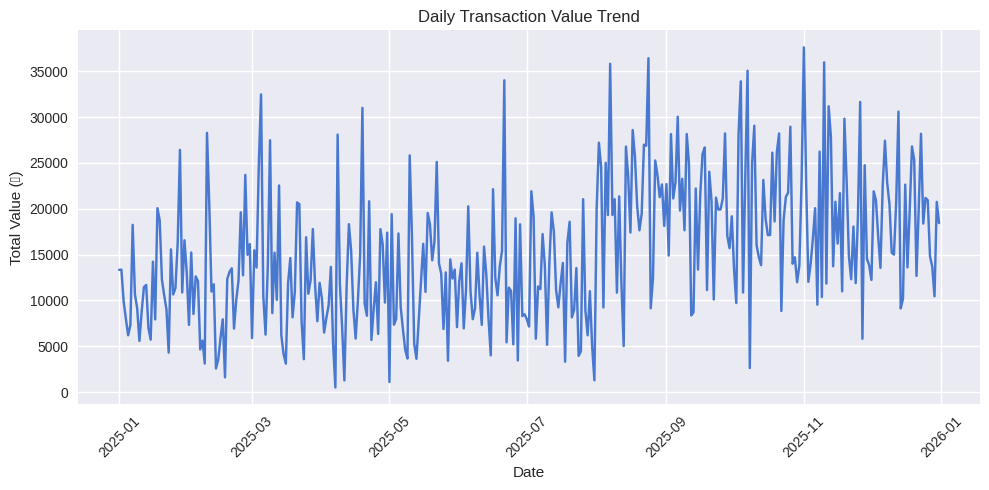

In [47]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
txn_trend = df.groupby(df['Date'].dt.date)['Transaction_Amount'].sum()

plt.figure(figsize=(10,5))
txn_trend.plot(kind='line')
plt.title("Daily Transaction Value Trend")
plt.xlabel("Date")
plt.ylabel("Total Value (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Daily Transaction Value Trend", dpi=300)
plt.show()

## 6. Daily Transaction Count Trend

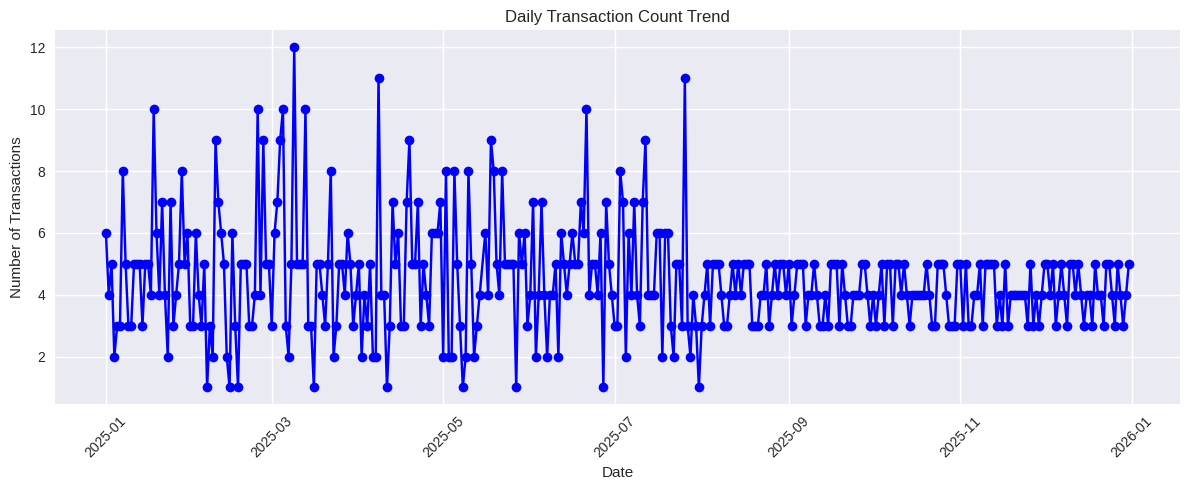

In [48]:
# Group by date and count transactions
daily_count = df.groupby(df['Date'].dt.date)['Transaction_ID'].count()

# Plot daily transaction count
fig, ax = plt.subplots(figsize=(12,5))
daily_count.plot(kind='line', marker='o', color='blue', ax=ax, title='Daily Transaction Count Trend')

plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Daily Transaction Count Trend", dpi=300)
plt.show()


## 7. Monthly Transaction Value Trend

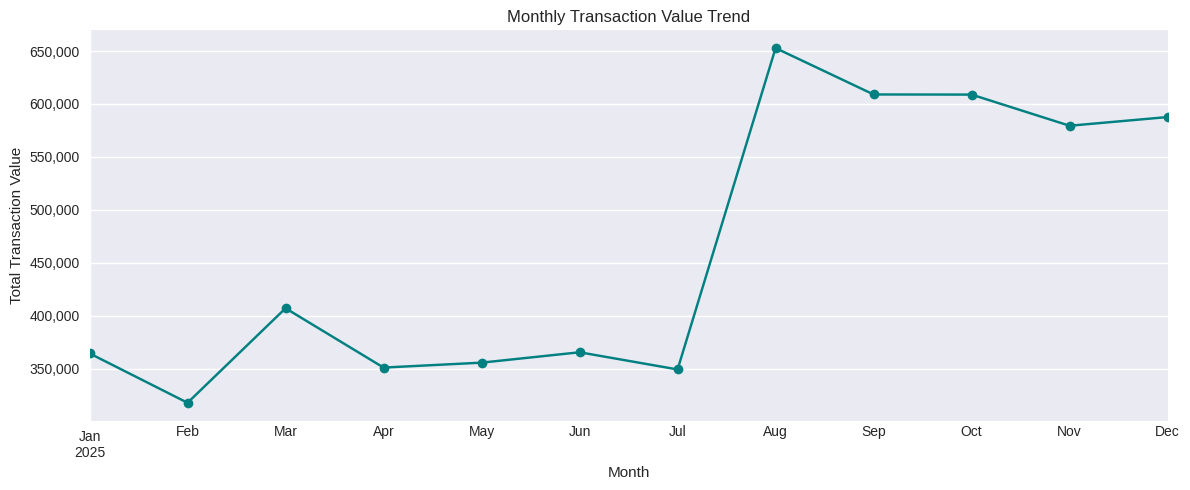

In [49]:
# Create a month column (Year-Month)
df['Month'] = df['Date'].dt.to_period('M')

# Aggregate monthly transaction values
monthly_value = df.groupby('Month')['Transaction_Amount'].sum()

# Plot monthly transaction values
fig, ax = plt.subplots(figsize=(12,5))
monthly_value.plot(kind='line', marker='o', color='teal', ax=ax, title='Monthly Transaction Value Trend')

# Format y-axis with commas
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.xlabel('Month')
plt.ylabel('Total Transaction Value')
plt.tight_layout()
plt.savefig("Monthly Transaction Value Trend", dpi=300)
plt.show()


## 8. Monthly Transaction Count Trend

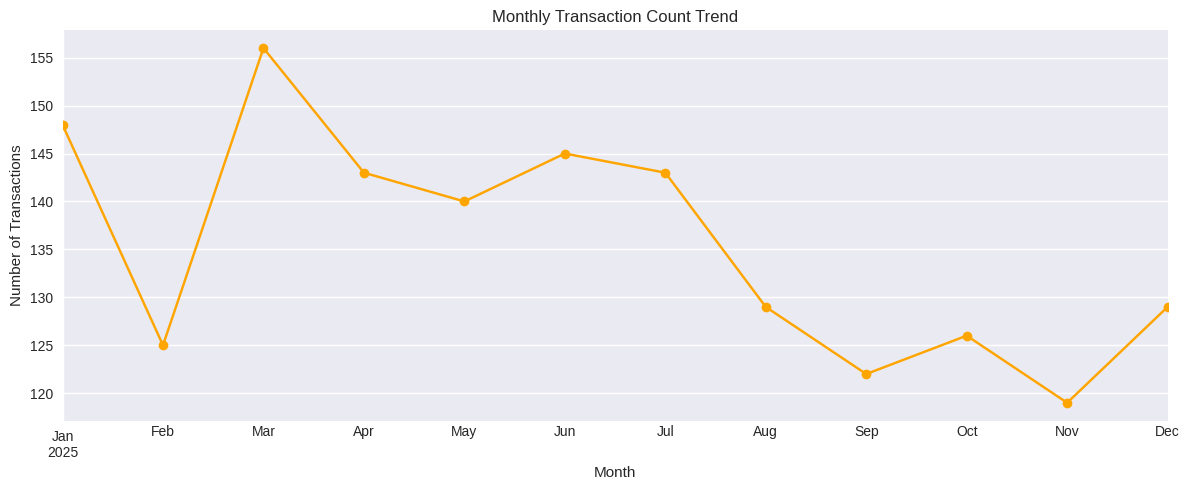

In [50]:
# Aggregate monthly transaction counts
monthly_count = df.groupby('Month')['Transaction_ID'].count()

# Plot monthly transaction counts
fig, ax = plt.subplots(figsize=(12,5))
monthly_count.plot(kind='line', marker='o', color='orange', ax=ax, title='Monthly Transaction Count Trend')

plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig("Monthly Transaction Count Trend", dpi=300)
plt.show()


## 9. Quarterly Transaction Value Bar Graph


/tmp/ipykernel_2133/4111191951.py:9: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_value = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(


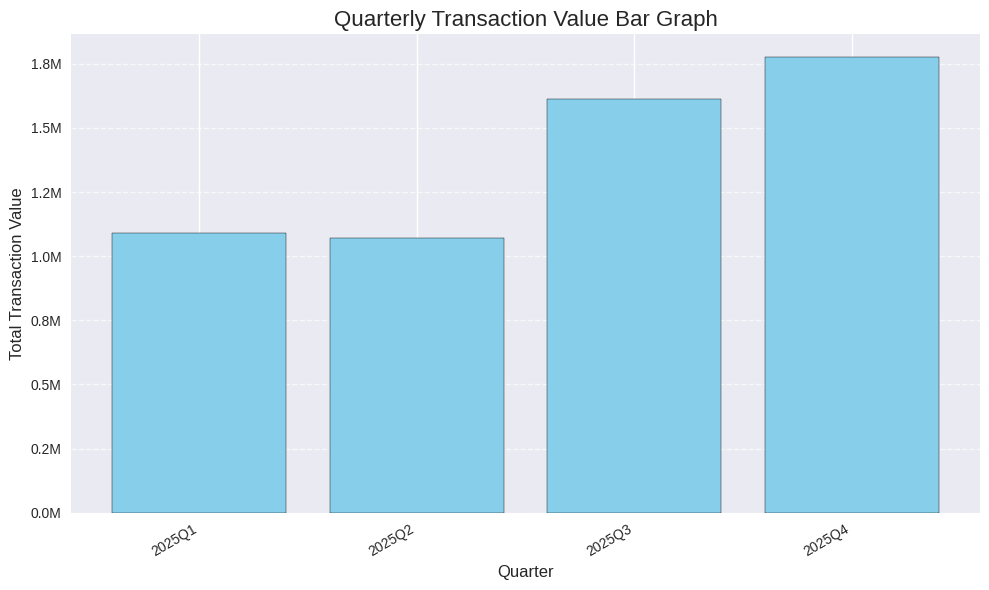

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Group by quarter for transaction value
quarterly_value = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
    Total_Value=("Transaction_Amount", "sum")
).reset_index()

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(quarterly_value["Date"].dt.to_period("Q").astype(str),
        quarterly_value["Total_Value"],
        color="skyblue", edgecolor="black")

plt.title("Quarterly Transaction Value Bar Graph", fontsize=16)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Total Transaction Value", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Format y-axis to show values in millions instead of 1e6
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig("Quarterly Transaction Value Bar Graph", dpi=300)
plt.show()


## 10. Quarterly Transaction Count Bar Graph


/tmp/ipykernel_2133/1145391772.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_count = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(


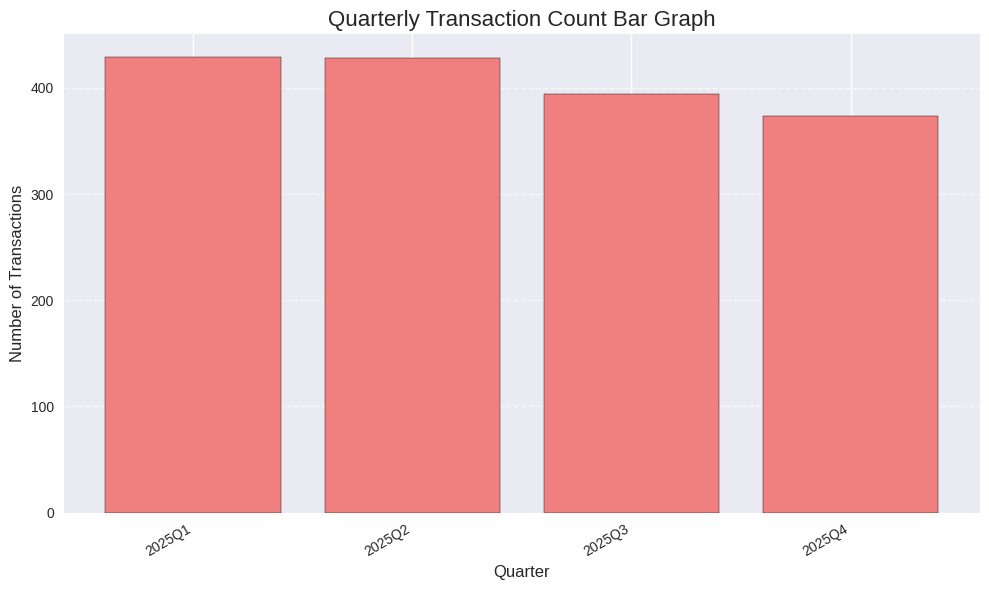

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Group by quarter for transaction count
quarterly_count = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
    Total_Transactions=("Transaction_ID", "count")
).reset_index()

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(quarterly_count["Date"].dt.to_period("Q").astype(str),
        quarterly_count["Total_Transactions"],
        color="lightcoral", edgecolor="black")

plt.title("Quarterly Transaction Count Bar Graph", fontsize=16)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("Quarterly Transaction Count Bar Graph", dpi=300)
plt.show()


## 11. Payment Method Analysis Pie Chart
Understanding which payment methods are most popular among customers.

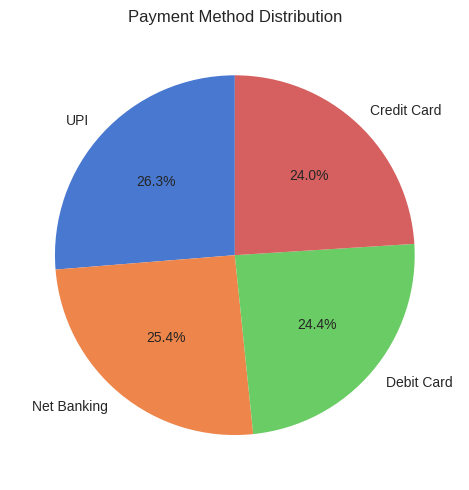

In [53]:
plt.figure(figsize=(7,5))
df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig("Payment Method Analysis Pie Chart", dpi=300)
plt.show()

## 12. Location-wise Bar Graph – Transaction Value

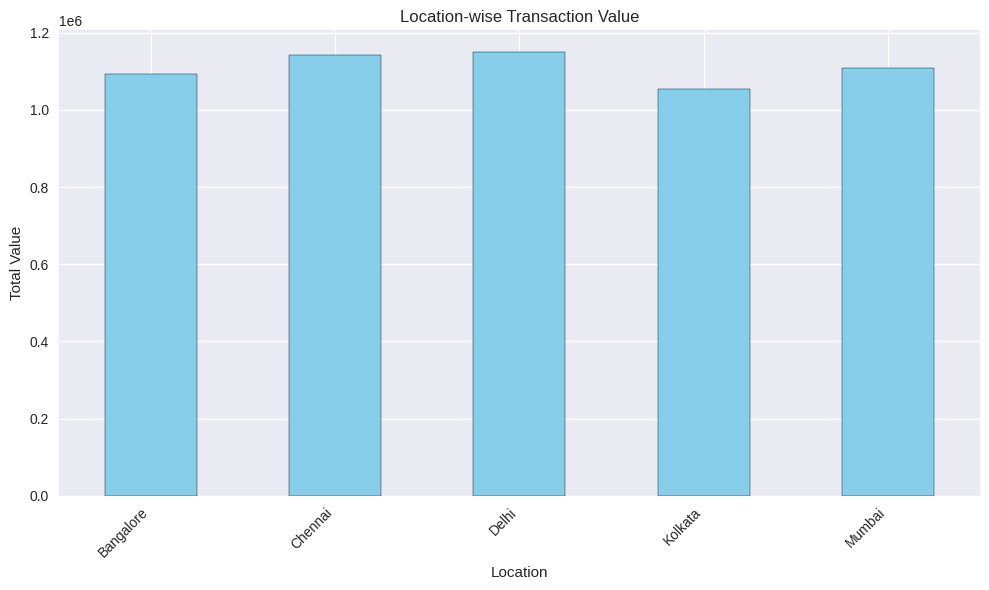

In [54]:
df.groupby("Location")["Transaction_Amount"].sum().plot.bar(
    figsize=(10,6), color="skyblue", edgecolor="black"
)
plt.title("Location-wise Transaction Value")
plt.xlabel("Location")
plt.ylabel("Total Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Location-wise Bar Graph – Transaction Value", dpi=300)
plt.show()


## 13. Location-wise Bar Graph – Number of Transactions

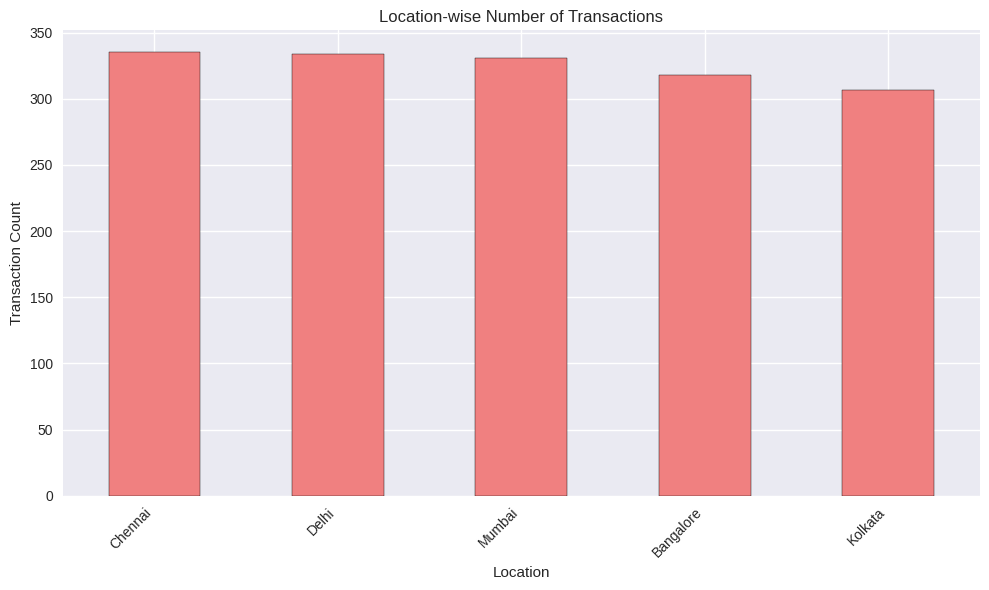

In [55]:
df["Location"].value_counts().plot.bar(
    figsize=(10,6), color="lightcoral", edgecolor="black"
)
plt.title("Location-wise Number of Transactions")
plt.xlabel("Location")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Location-wise Bar Graph – Number of Transactions", dpi=300)
plt.show()


## 14. Transaction Status Pie Chart
We check the success vs failure distribution of transactions.

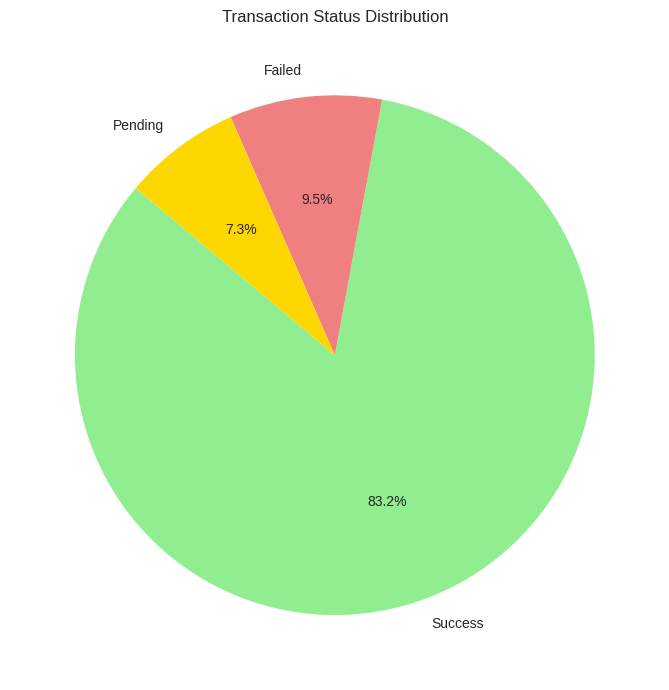

In [56]:
df["Transaction_Status"].value_counts().plot.pie(
    autopct="%1.1f%%", figsize=(7,7), startangle=140, colors=["lightgreen","lightcoral","gold"]
)
plt.title("Transaction Status Distribution")
plt.ylabel("")  # hides y-axis label
plt.tight_layout()
plt.savefig("Transaction Status Pie Chart", dpi=300)
plt.show()


## 15. Top 5 Merchants Bar Graph
We identify the top 5 merchants by total transaction value.

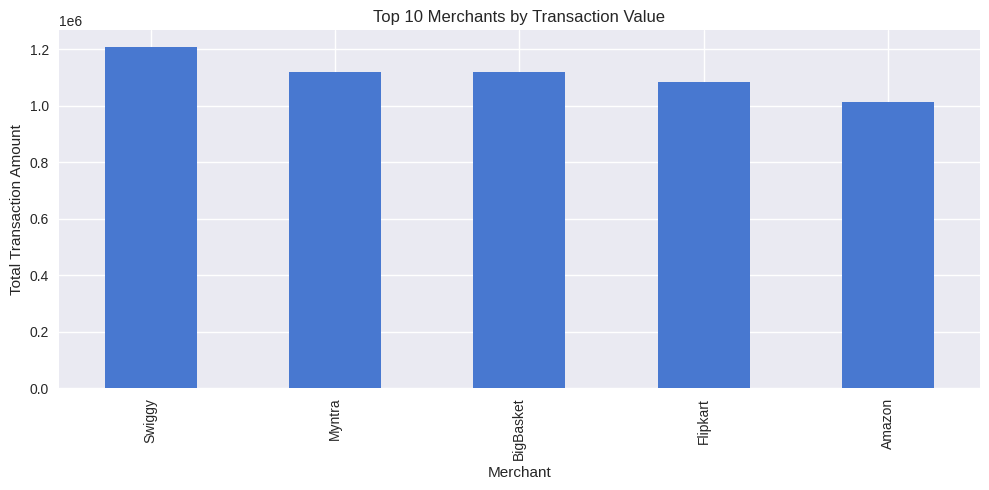

In [57]:
top_merchants1 = df.groupby('Merchant_Name')['Transaction_Amount'].sum().sort_values(ascending=False).head(10)
top_merchants1.plot(kind='bar', figsize=(10,5), title='Top 10 Merchants by Transaction Value')
plt.xlabel('Merchant')
plt.ylabel('Total Transaction Amount')
plt.tight_layout()
plt.savefig("Top 5 Merchants Bar Graph", dpi=300)
plt.show()

## 16. Top 10 Customers Bar Graph
We identify the top 10 customers who contributed the most in terms of transaction value.

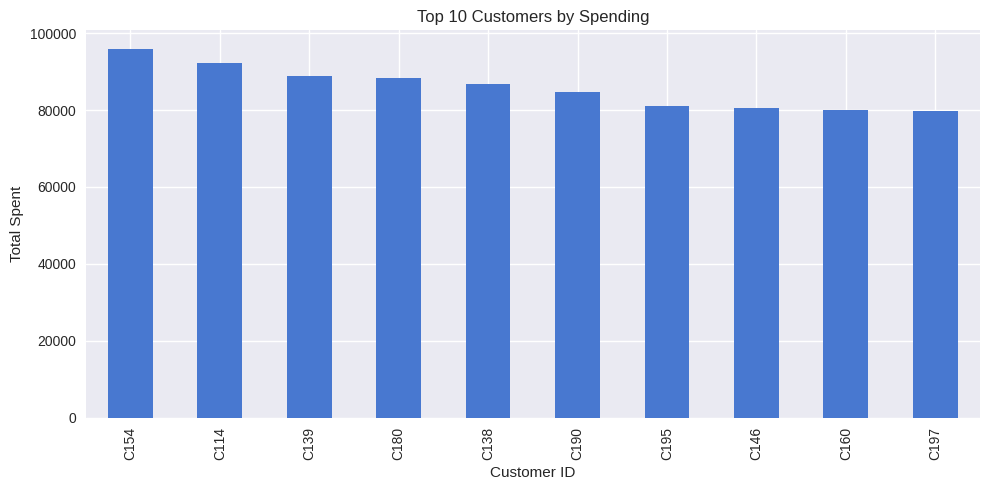

In [58]:
top_customers1 = df.groupby('Customer_ID')['Transaction_Amount'].sum().sort_values(ascending=False).head(10)
top_customers1.plot(kind='bar', figsize=(10,5), title='Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spent')
plt.tight_layout()
plt.savefig("Top 10 Customers Bar Graph", dpi=300)
plt.show()

## 17. Top 5 Merchants (no. of transactions) Bar Graph

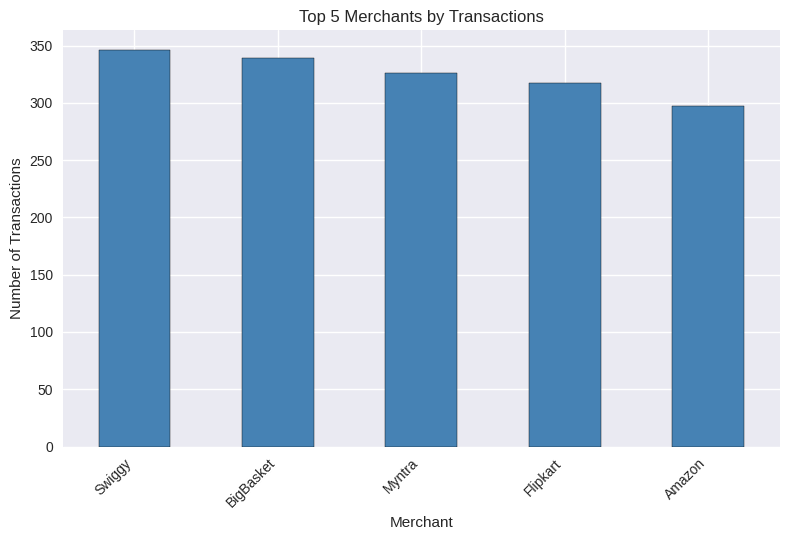

In [59]:
top_merchants2 = df["Merchant_Name"].value_counts().head(5)

# Bar chart
top_merchants2.plot.bar(color="steelblue", edgecolor="black")
plt.title("Top 5 Merchants by Transactions")
plt.xlabel("Merchant")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Top 5 Merchants transaction number Bar Graph", dpi=300)
plt.show()


## 18. Top 10 Customers (no. of transactions) Bar Graph

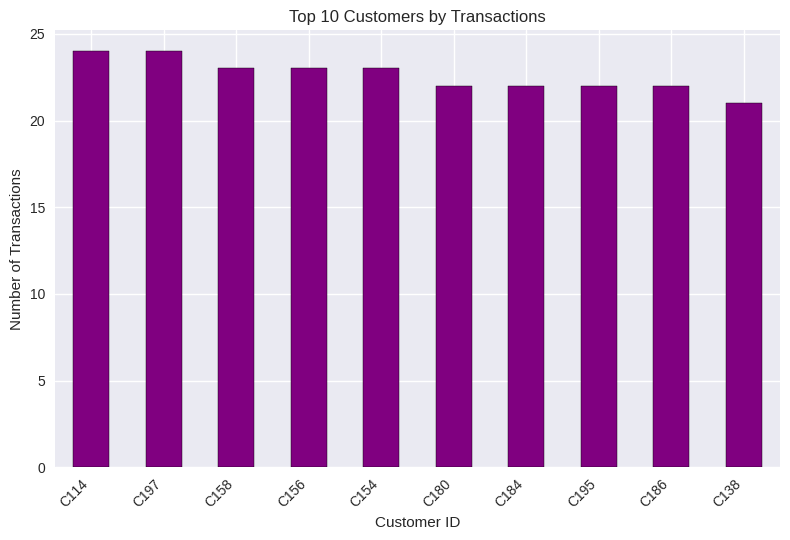

In [60]:
top_customers2 = df["Customer_ID"].value_counts().head(10)

top_customers2.plot.bar(color="purple", edgecolor="black")
plt.title("Top 10 Customers by Transactions")
plt.xlabel("Customer ID")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Top 10 customers transaction number Bar Graph", dpi=300)
plt.show()


## 19. High Value Transactions greater than 4000


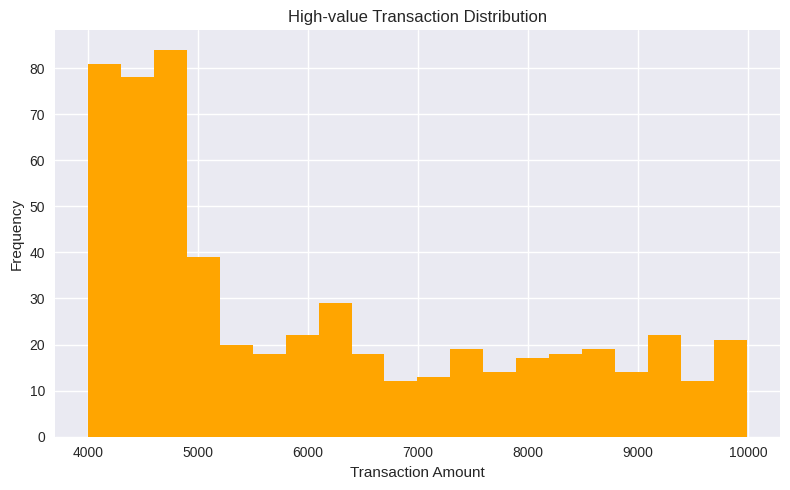

In [61]:
high_value = df[df['Transaction_Amount'] > 4000]
high_value['Transaction_Amount'].hist(bins=20, figsize=(8,5), color='orange')
plt.title('High-value Transaction Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("High Value Transactions greater than 4000", dpi=300)
plt.show()

## 20. Failed Transaction Rate per Payment Method

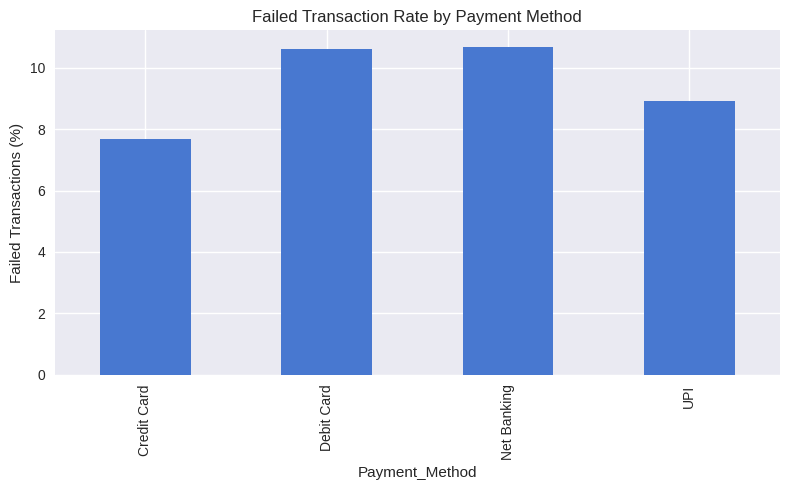

In [62]:
failed_rate = df[df['Transaction_Status'] == 'Failed'].groupby('Payment_Method').size() / df.groupby('Payment_Method').size() * 100
failed_rate.plot(kind='bar', figsize=(8,5), title='Failed Transaction Rate by Payment Method')
plt.ylabel('Failed Transactions (%)')
plt.tight_layout()
plt.savefig("Failed Transaction Rate per Payment Method", dpi=300)
plt.show()

##21. Exporting the data of analysis in csv files


In [63]:
txn_trend.to_csv('txn_trend.csv')
daily_count.to_csv('daily_count.csv')
monthly_value.to_csv('monthly_value.csv')
monthly_count.to_csv('monthly_count.csv')
quarterly_value.to_csv('quarterly_value.csv')
quarterly_count.to_csv('quarterly_count.csv')

payment_summary = df.groupby("Payment_Method").agg(
    Total_Transactions=("Transaction_ID", "count"),
    Total_Value=("Transaction_Amount", "sum")
).reset_index()
payment_summary.to_csv('payment_summary.csv')

location_value = df.groupby("Location")["Transaction_Amount"].sum().reset_index()
location_value.columns = ["Location", "Total_Value"]
location_value.to_csv('location_value.csv')

location_count = df["Location"].value_counts().reset_index()
location_count.columns = ["Location", "Transaction_Count"]
location_count.to_csv('location_count.csv')

status_summary = df["Transaction_Status"].value_counts().reset_index()
status_summary.columns = ["Transaction_Status", "Count"]
status_summary.to_csv('status_summary.csv')

top_merchants1.to_csv('top_merchants1.csv')
top_customers1.to_csv('top_customers1.csv')
top_merchants2.to_csv('top_merchants2.csv')
top_customers2.to_csv('top_customers2.csv')
high_value.to_csv('high_value.csv')
failed_rate.to_csv('failed_rate.csv')

##22. Generating a pdf with all the bar graphs, pie charts, line graphs, histograms


In [64]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

with PdfPages("maddoxpay_graphs_final.pdf") as pdf:

    txn_trend = df.groupby(df['Date'].dt.date)['Transaction_Amount'].sum()

    plt.figure(figsize=(10,5))
    txn_trend.plot(kind='line')
    plt.title("Daily Transaction Value Trend")
    plt.xlabel("Date")
    plt.ylabel("Total Value (₹)")
    plt.xticks(rotation=45)
    pdf.savefig()
    plt.close()



    # Group by date and count transactions
    daily_count = df.groupby(df['Date'].dt.date)['Transaction_ID'].count()

    # Plot daily transaction count
    fig, ax = plt.subplots(figsize=(12,5))
    daily_count.plot(kind='line', marker='o', color='blue', ax=ax, title='Daily Transaction Count Trend')

    plt.xlabel('Date')
    plt.ylabel('Number of Transactions')
    plt.xticks(rotation=45)
    pdf.savefig()
    plt.close()



    # Create a month column (Year-Month)
    df['Month'] = df['Date'].dt.to_period('M')

    # Aggregate monthly transaction values
    monthly_value = df.groupby('Month')['Transaction_Amount'].sum()

    # Plot monthly transaction values
    fig, ax = plt.subplots(figsize=(12,5))
    monthly_value.plot(kind='line', marker='o', color='teal', ax=ax, title='Monthly Transaction Value Trend')

    # Format y-axis with commas
    import matplotlib.ticker as mtick
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

    plt.xlabel('Month')
    plt.ylabel('Total Transaction Value')
    pdf.savefig()
    plt.close()



    # Aggregate monthly transaction counts
    monthly_count = df.groupby('Month')['Transaction_ID'].count()

    # Plot monthly transaction counts
    fig, ax = plt.subplots(figsize=(12,5))
    monthly_count.plot(kind='line', marker='o', color='orange', ax=ax, title='Monthly Transaction Count Trend')

    plt.xlabel('Month')
    plt.ylabel('Number of Transactions')
    pdf.savefig()
    plt.close()







    # Ensure Date is datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Group by quarter for transaction value
    quarterly_value = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
    Total_Value=("Transaction_Amount", "sum")
    ).reset_index()

    # Plot bar chart
    plt.figure(figsize=(10,6))
    plt.bar(quarterly_value["Date"].dt.to_period("Q").astype(str),
        quarterly_value["Total_Value"],
        color="skyblue", edgecolor="black")

    plt.title("Quarterly Transaction Value Bar Graph", fontsize=16)
    plt.xlabel("Quarter", fontsize=12)
    plt.ylabel("Total Transaction Value", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Format y-axis to show values in millions instead of 1e6
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    pdf.savefig()
    plt.close()






    # Ensure Date is datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Group by quarter for transaction count
    quarterly_count = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
    Total_Transactions=("Transaction_ID", "count")
    ).reset_index()

    # Plot bar chart
    plt.figure(figsize=(10,6))
    plt.bar(quarterly_count["Date"].dt.to_period("Q").astype(str),
        quarterly_count["Total_Transactions"],
        color="lightcoral", edgecolor="black")

    plt.title("Quarterly Transaction Count Bar Graph", fontsize=16)
    plt.xlabel("Quarter", fontsize=12)
    plt.ylabel("Number of Transactions", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    pdf.savefig()
    plt.close()



    plt.figure(figsize=(7,5))
    df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title("Payment Method Distribution")
    plt.ylabel("")
    pdf.savefig()
    plt.close()


    df.groupby("Location")["Transaction_Amount"].sum().plot.bar(
    figsize=(10,6), color="skyblue", edgecolor="black"
    )
    plt.title("Location-wise Transaction Value")
    plt.xlabel("Location ")
    plt.ylabel("Total Value")
    plt.xticks(rotation=45, ha="right")
    pdf.savefig()
    plt.close()



    df["Location"].value_counts().plot.bar(
    figsize=(10,6), color="lightcoral", edgecolor="black"
    )
    plt.title("Location-wise Number of Transactions")
    plt.xlabel("Location")
    plt.ylabel("Transaction Count")
    plt.xticks(rotation=45, ha="right")
    pdf.savefig()
    plt.close()


    df["Transaction_Status"].value_counts().plot.pie(
    autopct="%1.1f%%", figsize=(7,7), startangle=140, colors=["lightgreen","lightcoral","gold"]
    )
    plt.title("Transaction Status Distribution")
    plt.ylabel("")  # hides y-axis label
    pdf.savefig()
    plt.close()


    top_merchants1 = df.groupby('Merchant_Name')['Transaction_Amount'].sum().sort_values(ascending=False).head(10)
    top_merchants1.plot(kind='bar', figsize=(10,5), title='Top 10 Merchants by Transaction Value')
    plt.xlabel('Merchant')
    plt.ylabel('Total Transaction Amount')
    pdf.savefig()
    plt.close()


    top_customers1 = df.groupby('Customer_ID')['Transaction_Amount'].sum().sort_values(ascending=False).head(10)
    top_customers1.plot(kind='bar', figsize=(10,5), title='Top 10 Customers by Spending')
    plt.xlabel('Customer ID')
    plt.ylabel('Total Spent')
    pdf.savefig()
    plt.close()



    top_merchants2 = df["Merchant_Name"].value_counts().head(5)

    # Bar chart
    top_merchants2.plot.bar(color="steelblue", edgecolor="black")
    plt.title("Top 5 Merchants by Transactions")
    plt.xlabel("Merchant")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45, ha="right")
    pdf.savefig()
    plt.close()



    top_customers2 = df["Customer_ID"].value_counts().head(10)

    top_customers2.plot.bar(color="purple", edgecolor="black")
    plt.title("Top 10 Customers by Transactions")
    plt.xlabel("Customer ID")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=45, ha="right")
    pdf.savefig()
    plt.close()



    high_value = df[df['Transaction_Amount'] > 4000]
    high_value['Transaction_Amount'].hist(bins=20, figsize=(8,5), color='orange')
    plt.title('High-value Transaction Distribution')
    plt.xlabel('Transaction Amount')
    plt.ylabel('Frequency')
    pdf.savefig()
    plt.close()



    failed_rate = df[df['Transaction_Status'] == 'Failed'].groupby('Payment_Method').size() / df.groupby('Payment_Method').size() * 100
    failed_rate.plot(kind='bar', figsize=(8,5), title='Failed Transaction Rate by Payment Method')
    plt.ylabel('Failed Transactions (%)')
    pdf.savefig()
    plt.close()


print("✅ All graphs saved into one file: maddoxpay_graphs.pdf")

/tmp/ipykernel_2133/206596964.py:14: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  pdf.savefig()
/tmp/ipykernel_2133/206596964.py:77: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_value = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(
/tmp/ipykernel_2133/206596964.py:108: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_count = df.groupby(pd.Grouper(key="Date", freq="Q")).agg(


✅ All graphs saved into one file: maddoxpay_graphs.pdf


##23. Export tabluar data corresponding to data visuals in single excel sheet


In [65]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# --- Helper to clean DataFrames (fix Period dtype issue) ---
def clean_dataframe(df):
    # Convert Series to DataFrame
    if not isinstance(df, pd.DataFrame):
        df = df.reset_index()

    # Convert Period columns (Monthly, Quarterly) to string
    for col in df.columns:
        if pd.api.types.is_period_dtype(df[col]):
            df[col] = df[col].astype(str)
    return df.reset_index(drop=True)

# --- Prepare your tables ---
tables = [
    ("Txn_Trend", clean_dataframe(txn_trend)),
    ("Daily_Count", clean_dataframe(daily_count)),
    ("Monthly_Value", clean_dataframe(monthly_value)),
    ("Monthly_Count", clean_dataframe(monthly_count)),
    ("Quarterly_Value", clean_dataframe(quarterly_value)),
    ("payment_summary", clean_dataframe(payment_summary)),
    ("location_value", clean_dataframe(location_value)),
    ("location_count", clean_dataframe(location_count)),
    ("status_summary", clean_dataframe(status_summary)),
    ("top_merchants1", clean_dataframe(top_merchants1)),
    ("top_customers1", clean_dataframe(top_customers1)),
    ("top_merchants2", clean_dataframe(top_merchants2)),
    ("top_customers2", clean_dataframe(top_customers2)),
    ("high_value", clean_dataframe(high_value)),
    ("failed_rate", clean_dataframe(failed_rate)),

]

# If any table is empty, replace with placeholder
for i, (name, df_part) in enumerate(tables):
    if df_part is None or df_part.shape[0] == 0:
        tables[i] = (name, pd.DataFrame([["No data"]], columns=["Info"]))

# Find max number of columns across all tables (for title merging)
max_cols = max(df_part.shape[1] for _, df_part in tables)
if max_cols < 1:
    max_cols = 1

# --- Create workbook ---
wb = Workbook()
ws = wb.active
ws.title = "Summary"

# Styles
title_fill = PatternFill("solid", fgColor="4F81BD")   # dark blue
title_font  = Font(bold=True, color="FFFFFF", size=12)
header_fill = PatternFill("solid", fgColor="BDD7EE")  # light blue
header_font = Font(bold=True)

start_row = 1

for name, df_part in tables:
    # 1) Section Title
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=max_cols)
    title_cell = ws.cell(row=start_row, column=1, value=f" {name} ")
    title_cell.font = title_font
    title_cell.fill = title_fill
    title_cell.alignment = Alignment(horizontal="center", vertical="center")
    start_row += 1

    # 2) Write DataFrame rows (headers + values)
    rows = list(dataframe_to_rows(df_part, index=False, header=True))
    for r_idx, row in enumerate(rows):
        for c_idx, value in enumerate(row, start=1):
            cell = ws.cell(row=start_row + r_idx, column=c_idx, value=value)
            # style header row
            if r_idx == 0:
                cell.font = header_font
                cell.fill = header_fill

    # Update starting row for next table (table size + 2 blank rows)
    start_row += len(rows) + 2

# 3) Auto-adjust column widths
for col_idx in range(1, max_cols + 1):
    col_letter = get_column_letter(col_idx)
    max_length = 0
    for cell in ws[col_letter]:
        if cell.value is not None:
            length = len(str(cell.value))
            if length > max_length:
                max_length = length
    ws.column_dimensions[col_letter].width = max_length + 2

# 4) Save workbook
out_path = "all_tables_one_sheet.xlsx"
wb.save(out_path)
print("✅ Saved:", out_path)


✅ Saved: all_tables_one_sheet.xlsx


/tmp/ipykernel_2133/669816371.py:15: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):
/tmp/ipykernel_2133/669816371.py:15: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):
/tmp/ipykernel_2133/669816371.py:15: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):
/tmp/ipykernel_2133/669816371.py:15: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):
/tmp/ipykernel_2133/669816371.py:15: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future v